# Sanskrit / English Semantic Retrieval — Fine-tuning `multilingual-e5-small`

**Assignment Option 2:** fine-tune a multilingual embedding model for Sanskrit/English semantic
search, evaluate with Recall@K / MRR / nDCG, and demonstrate a mini-RAG pipeline.

**Why this track:** it is the only option that yields a clean, label-free, quantitative before/after
— parallel verses supply 1:1 relevance labels for free — on a single Colab T4 in well under a day.
Full reasoning and the rejected tracks are in `02-decision-memo.md`; model/data/training rationale
(with rejected alternatives) is in `03-technical-design.md`.

**Run order:** Setup → Data → Tokenizer diagnostic → Baseline → Train → Before/after → OOD eval →
RAG demo → Failure analysis → Save → Bonus. Set the runtime to GPU (T4).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup — mount Google Drive, set the project folder, install deps
Upload the `sanskrit-assignment` folder to Drive, then set **`PROJECT_DIR`** below to its path. All
code, checkpoints, weights, results, and charts read from and write to that one folder on Drive, so
nothing is lost when the Colab runtime resets.


In [2]:
# Mount Drive so the project folder and all outputs persist on Drive.
from google.colab import drive
drive.mount('/content/drive')

import os, sys
# vvv EDIT to match the uploaded folder path (in Colab, MyDrive = /content/drive/MyDrive/) vvv
PROJECT_DIR = "/content/drive/MyDrive/sanskrit-assignment"
assert os.path.isdir(PROJECT_DIR), (
    f"'{PROJECT_DIR}' not found. Upload the folder to Drive and set PROJECT_DIR to its exact path."
)
os.chdir(PROJECT_DIR)                              # relative paths now resolve inside the Drive folder
sys.path.insert(0, os.path.join(PROJECT_DIR, "src"))

!pip -q install "sentence-transformers>=3.0" "datasets>=2.20" faiss-cpu indic-transliteration sacrebleu

import torch
print("Project:", PROJECT_DIR)
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.2 MB/s eta 0:00:00
Project: /content/drive/MyDrive/sanskrit-assignment
CUDA: True Tesla T4


### Hugging Face login (optional — unlocks the gated OOD eval sets)
Enables the out-of-domain number from **AI4Bharat IN22** / **FLORES**. Optional: without it the OOD
cell falls back to the ungated **Bhagavad Gita** cross-domain eval, so nothing breaks. Prereqs (once):
create a **Read** token at [hf.co/settings/tokens](https://huggingface.co/settings/tokens), and click
**"Agree and access"** on the [IN22](https://huggingface.co/datasets/ai4bharat/IN22-Gen) and
[FLORES](https://huggingface.co/datasets/openlanguagedata/flores_plus) dataset pages while signed in.


In [3]:
from huggingface_hub import notebook_login
notebook_login()   # paste a READ token in the widget
# Non-interactive alternative:
#   from huggingface_hub import login; login(token="hf_xxx")
# Colab Secrets alternative:
#   from google.colab import userdata; from huggingface_hub import login; login(token=userdata.get("HF_TOKEN"))


In [4]:
from sanskrit_retrieval.config import DEFAULT
from sanskrit_retrieval import data, model as M, train as T, evaluate as E, index as IX, rag
import numpy as np, random, json

# Persist checkpoints/weights and results into the Drive project folder.
cfg = DEFAULT.with_(output_dir=os.path.join(PROJECT_DIR, "artifacts"))
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(cfg.output_dir, exist_ok=True); os.makedirs(RESULTS_DIR, exist_ok=True)
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
print("checkpoints/weights ->", cfg.output_dir)
print("results/metrics/charts ->", RESULTS_DIR)
cfg  # override for experiments with cfg.with_(batch_size=128, epochs=2, ...)


checkpoints/weights -> /content/drive/MyDrive/sanskrit-assignment/artifacts
results/metrics/charts -> /content/drive/MyDrive/sanskrit-assignment/results


Config(base_model='intfloat/multilingual-e5-small', query_prefix='query: ', passage_prefix='passage: ', max_seq_len=128, normalize_embeddings=True, itihasa_id='rahular/itihasa', gita_id='JDhruv14/Bhagavad-Gita_Dataset', in22_id='ai4bharat/IN22-Gen', in22_config='all', in22_split='gen', in22_sa_col='sentence_san_Deva', in22_en_col='sentence_eng_Latn', flores_id='openlanguagedata/flores_plus', flores_sanskrit='san_Deva', iast_augment_ratio=0.25, dedup=True, batch_size=64, epochs=1, learning_rate=2e-05, warmup_ratio=0.1, use_fp16=True, both_directions=True, hard_neg_margin=0.05, hard_neg_range_min=25, k_values=(1, 5, 10), eval_max_corpus=2000, seed=42, output_dir='/content/drive/MyDrive/sanskrit-assignment/artifacts', run_name='e5-small-sa-en-mnrl')

## 2. Data
Load `rahular/itihasa` (~93K aligned Sanskrit/English verse pairs), normalize to Unicode NFC, build
**directional** prefixed pairs (Sa->En and En->Sa), augment a fraction with **IAST** (transliteration
robustness), and dedup. Held-out eval uses **AI4Bharat IN22** or the ungated **Bhagavad Gita**
(out-of-domain); the Gita also backs the RAG demo — all from the assignment's suggested list.


In [5]:
sa_train, en_train = data.load_itihasa("train")
sa_test,  en_test  = data.load_itihasa("test")
print(f"Itihasa train rows: {len(sa_train):,} | test rows: {len(sa_test):,}")
print("sample SA:", sa_train[0][:60], "\nsample EN:", en_train[0][:60])


train.sn.csv:   0%|          | 0.00/20.6M [00:00<?, ?B/s]

train.en.csv:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

test.sn.csv:   0%|          | 0.00/3.20M [00:00<?, ?B/s]

test.en.csv:   0%|          | 0.00/2.09M [00:00<?, ?B/s]

Itihasa train rows: 75,161 | test rows: 11,721
sample SA: ॐ तपः स्वाध्यायनिरतं तपस्वी वाग्विदां वरम्। नारदं परिपप्रच्छ 
sample EN: The ascetic Vālmīki asked Nārada, the best of sages and fore


In [6]:
pairs = data.build_pairs(sa_train, en_train, cfg)          # directional + prefixed
pairs += data.augment_iast(sa_train, en_train, cfg)        # IAST variants (needs indic-transliteration)
pairs = data.dedup_pairs(pairs)
print(f"training pairs after dedup: {len(pairs):,}")
print("example:", pairs[0])


training pairs after dedup: 168,783
example: {'anchor': 'query: ॐ तपः स्वाध्यायनिरतं तपस्वी वाग्विदां वरम्। नारदं परिपप्रच्छ वाल्मीकिर्मुनिपुङ्गवम्॥', 'positive': 'passage: The ascetic Vālmīki asked Nārada, the best of sages and foremost of those conversant with words, ever engaged in austerities and Vedic studies.', 'direction': 'sa2en'}


## 3. Tokenizer diagnostic (the script/tokenization question the spec calls out)
Fertility = mean subword tokens per word. A value >1 means Devanagari words fragment into multiple
subwords, burning context and learning signal. Measured and reported here; the tokenizer is not
retrained (out-of-scope rationale in `03 section 1`).


In [7]:
base_model = M.load_model(cfg)
sample_words = " ".join(sa_train[:50]).split()
fert = M.devanagari_fertility(base_model, sample_words)
print(f"e5-small Devanagari fertility: {fert:.2f} subword-tokens/word")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

e5-small Devanagari fertility: 3.36 subword-tokens/word


## 4. Baseline evaluation (before fine-tuning)
Build an `InformationRetrievalEvaluator` on the held-out Itihasa test set (in-domain): corpus =
English translations, queries = Sanskrit verses, gold = the aligned translation (1:1, zero manual
labeling). The out-of-domain evaluator is built later for the honest generalization number.


In [8]:
ir_indomain = E.build_ir_eval(sa_test, en_test, cfg)
baseline = E.evaluate_model(base_model, ir_indomain)
{k: round(v, 4) for k, v in baseline.items() if "cos" in k}


{'sa2en_cos_accuracy@1': 0.147,
 'sa2en_cos_accuracy@3': 0.2235,
 'sa2en_cos_accuracy@5': 0.266,
 'sa2en_cos_accuracy@10': 0.331,
 'sa2en_cos_precision@1': 0.147,
 'sa2en_cos_precision@5': 0.0532,
 'sa2en_cos_precision@10': 0.0331,
 'sa2en_cos_recall@1': 0.147,
 'sa2en_cos_recall@5': 0.266,
 'sa2en_cos_recall@10': 0.331,
 'sa2en_cos_ndcg@1': 0.147,
 'sa2en_cos_ndcg@5': 0.2094,
 'sa2en_cos_ndcg@10': 0.2302,
 'sa2en_cos_mrr@1': 0.147,
 'sa2en_cos_mrr@5': 0.1907,
 'sa2en_cos_mrr@10': 0.1992,
 'sa2en_cos_map@100': 0.2084}

## 5. Train — contrastive fine-tune (MultipleNegativesRankingLoss)
In-batch negatives: every other positive in the batch is a negative, so batch size is the negative
count — larger is better (set as high as VRAM allows). Runtime ~minutes to 1h on a T4.


In [9]:
train_model = M.load_model(cfg)            # fresh copy so base_model stays as the baseline
out_path = T.train(train_model, pairs, cfg)   # set cached=True for a large-effective-batch run
print("saved fine-tuned model to:", out_path)
tuned_model = M.load_model(cfg, checkpoint=out_path)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Step,Training Loss
500,0.959818
1000,0.310230
1500,0.238037
2000,0.208180
2500,0.190343


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved fine-tuned model to: /content/drive/MyDrive/sanskrit-assignment/artifacts/e5-small-sa-en-mnrl


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 6. Before/after — the headline result


In [10]:
import pandas as pd
ba = E.before_after(base_model, tuned_model, ir_indomain)
rows = []
for k in ba["before"]:
    if "cos" in k:
        rows.append({"metric": k, "before": ba["before"][k], "after": ba["after"][k], "delta": ba["delta"][k]})
df = pd.DataFrame(rows).round(4)
df.to_csv(os.path.join(RESULTS_DIR, "metrics_indomain.csv"), index=False)          # persist to Drive
json.dump(ba, open(os.path.join(RESULTS_DIR, "before_after_indomain.json"), "w"), indent=2)
df


,metric,before,after,delta
0,sa2en_cos_accuracy@1,0.1470,0.7890,0.6420
1,sa2en_cos_accuracy@3,0.2235,0.8825,0.6590
2,sa2en_cos_accuracy@5,0.2660,0.9105,0.6445
3,sa2en_cos_accuracy@10,0.3310,0.9370,0.6060
4,sa2en_cos_precision@1,0.1470,0.7890,0.6420
5,sa2en_cos_precision@5,0.0532,0.1821,0.1289
6,sa2en_cos_precision@10,0.0331,0.0937,0.0606
7,sa2en_cos_recall@1,0.1470,0.7890,0.6420
8,sa2en_cos_recall@5,0.2660,0.9105,0.6445
9,sa2en_cos_recall@10,0.3310,0.9370,0.6060


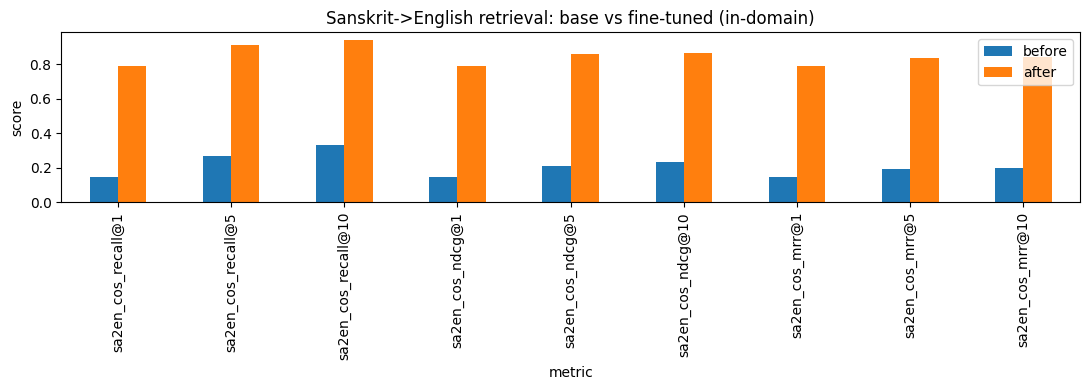

In [11]:
import matplotlib.pyplot as plt
plot_df = df[df["metric"].str.contains("recall|ndcg|mrr", case=False)].set_index("metric")[["before","after"]]
ax = plot_df.plot(kind="bar", figsize=(11,4), title="Sanskrit->English retrieval: base vs fine-tuned (in-domain)")
ax.set_ylabel("score"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "before_after_indomain.png"), dpi=150, bbox_inches="tight")
plt.show()


**Out-of-domain — the trustworthy generalization number.** Primary OOD set is **AI4Bharat IN22** (on the assignment's suggested list); **FLORES+** is the first fallback. Both are gated (need the HF login above). If neither is authorized, the ungated **Bhagavad Gita** provides a genuine cross-domain check (philosophical dialogue vs epic narrative); a held-out Itihasa slice is the final proxy. The eval set used is printed and saved.


In [12]:
try:
    sa_o, en_o = data.load_in22();               eval_tag = "AI4Bharat IN22 (out-of-domain)"
except Exception as e1:
    try:
        sa_o, en_o = data.load_flores_sanskrit("devtest"); eval_tag = "FLORES san_Deva (out-of-domain)"
    except Exception:
        try:
            sa_o, en_o = data.load_gita();       eval_tag = "Bhagavad Gita (ungated cross-domain)"
        except Exception:
            half = len(sa_test) // 2
            sa_o, en_o = sa_test[half:], en_test[half:]
            eval_tag = "Itihasa held-out slice (OOD PROXY — same domain)"
    print("Gated OOD unavailable; using ungated fallback.")

ir_ood = E.build_ir_eval(sa_o, en_o, cfg)
ood = E.before_after(base_model, tuned_model, ir_ood)
print("Eval set:", eval_tag)
ood_df = pd.DataFrame([{"metric": k, "before": ood["before"][k], "after": ood["after"][k]}
                       for k in ood["before"] if "cos" in k]).round(4)
ood_df.to_csv(os.path.join(RESULTS_DIR, "metrics_ood.csv"), index=False)            # persist to Drive
json.dump({"eval_set": eval_tag, **ood}, open(os.path.join(RESULTS_DIR, "before_after_ood.json"), "w"), indent=2)
ood_df


README.md:   0%|          | 0.00/7.71k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/73.7k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/952 [00:00<?, ?B/s]

geeta_dataset.csv:   0%|          | 0.00/677k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/701 [00:00<?, ? examples/s]

Gated OOD unavailable; using ungated fallback.
Eval set: Bhagavad Gita (ungated cross-domain)


,metric,before,after
0,sa2en_cos_accuracy@1,0.1740,0.7175
1,sa2en_cos_accuracy@3,0.2539,0.8659
2,sa2en_cos_accuracy@5,0.2981,0.9030
3,sa2en_cos_accuracy@10,0.3695,0.9401
4,sa2en_cos_precision@1,0.1740,0.7175
5,sa2en_cos_precision@5,0.0596,0.1806
6,sa2en_cos_precision@10,0.0369,0.0940
7,sa2en_cos_recall@1,0.1740,0.7175
8,sa2en_cos_recall@5,0.2981,0.9030
9,sa2en_cos_recall@10,0.3695,0.9401


## 7. Mini-RAG demo (Bhagavad Gita corpus)
Index the **Bhagavad Gita** English translations (701 verses, an assignment-suggested source) and
retrieve for natural-language queries — including the spec's *"what does this verse say about karma?"*
use case. The LLM answer step is optional (pass any `llm_fn`); retrieval quality shows without an API
key. If the Gita load fails, an Itihasa English slice keeps the demo running.


In [13]:
try:
    gita_sa, gita_en = data.load_gita()          # Bhagavad Gita, on-list, not gated
    passages = gita_en; sanskrit_query = gita_sa[0]; demo_tag = f"Bhagavad Gita ({len(passages)} verses)"
except Exception as e:
    print("Gita load failed -> Itihasa English slice. Detail:", e)
    passages = en_test[: cfg.eval_max_corpus]; sanskrit_query = sa_test[0]; demo_tag = "Itihasa slice (fallback)"
print("Demo corpus:", demo_tag)

vindex = IX.VerseIndex(tuned_model, passages, cfg)
demo = {"corpus": demo_tag, "queries": []}
for q in ["what does this verse say about karma?",
          "the duty of a warrior in battle",
          sanskrit_query]:  # a Sanskrit-script query
    hits = vindex.search(q, k=3)
    demo["queries"].append({"query": q, "hits": hits})
    print("Q:", q[:70])
    for hit in hits:
        print(f"   [{hit['rank']}] {hit['score']:.3f}  {hit['text'][:80]}")
    print()

# persist sample outputs to Drive (submission requirement: sample outputs)
json.dump(demo, open(os.path.join(RESULTS_DIR, "rag_demo_samples.json"), "w"), ensure_ascii=False, indent=2)

# Optional grounded answer:
# out = rag.answer(vindex, "what does this verse say about karma?", k=5, llm_fn=my_llm)
# print(out["answer"])


Demo corpus: Bhagavad Gita (701 verses)
Q: what does this verse say about karma?
   [1] 0.326  Arjuna said: Krishna, what is that Brahma, what is Adhyatma, and what is Karma? 
   [2] 0.305  Arjuna said: O Keshava, what is the description of a man of steady wisdom, who i
   [3] 0.292  One who is devoted to the path of selfless action attains lasting peace; one who

Q: the duty of a warrior in battle
   [1] 0.267  Besides: considering your own duty too you should not waver; for there is nothin
   [2] 0.214  Now, if you refuse to fight this righteous war, then, shirking your duty and los
   [3] 0.194  One’s own duty, though devoid of merit, is preferable to the duty of another wel

Q: धृतराष्ट्र उवाच |धर्मक्षेत्रे कुरुक्षेत्रे समवेता युयुत्सवः |मामकाः पा
   [1] 0.686  Dhritarashtra said: Sanjaya, gathered on the sacred soil of Kurukshetra, eager t
   [2] 0.463  Therefore, Krishna, it does not behove us to kill our relations, the sons of Dhr
   [3] 0.405  Krishna, how can we hope to be hap

## 8. Failure analysis
- **Transliteration robustness:** does the *same in-corpus verse* retrieve the same top-1 in
  Devanagari and in IAST? The query verse is present in the index, so the gold is retrievable;
  divergence between the two scripts signals the model routes them to different embedding regions.
- **Qualitative misses:** near-duplicate verses, domain shift (archaic epic English vs modern query).


In [14]:
from sanskrit_retrieval.normalize import to_iast, detect_script
dv = sanskrit_query                       # a verse that IS in the demo index (its gold is retrievable)
iast = to_iast(dv)
dv_top   = vindex.search(dv, k=1)[0]["text"]
iast_top = vindex.search(iast, k=1)[0]["text"]
print("Devanagari query script:", detect_script(dv), "| IAST query script:", detect_script(iast))
print("Devanagari top-1:", dv_top[:80])
print("IAST       top-1:", iast_top[:80])
print("same verse retrieved by both scripts:", dv_top == iast_top)


Devanagari query script: devanagari | IAST query script: latin
Devanagari top-1: Dhritarashtra said: Sanjaya, gathered on the sacred soil of Kurukshetra, eager t
IAST       top-1: Dhritarashtra said: Sanjaya, gathered on the sacred soil of Kurukshetra, eager t
same verse retrieved by both scripts: True


## 9. Save & next
Everything persists to the Drive project folder (survives runtime resets):
- **Weights + checkpoint:** `artifacts/<run_name>/` (SentenceTransformer model + tokenizer) — the deliverable checkpoint.
- **Metrics:** `results/metrics_indomain.csv`, `results/metrics_ood.csv` (+ `before_after_*.json`).
- **Chart:** `results/before_after_indomain.png`.
- **Sample outputs:** `results/rag_demo_samples.json`.
- **Bonus results:** `results/bonus_*.csv|json`.

**Iteration log:** record each run's config + metrics in `report/REPORT.md` — batch size, epochs,
IAST ratio, hard negatives, e5-small vs e5-base. That table is the debug-and-iterate evidence.

**Honesty note:** 1:1 verse retrieval is *translation retrieval* — easier than open thematic QA.
Absolute scores stay modest (low-resource + tiny model); the result is the *relative* before/after
and the methodology, not SOTA.


## 10. Bonus experiments (optional — spec "Bonus" section)
Three self-contained experiments, each reusing the same modules. Run any subset; each saves its
results to `results/`.


### 10a. e5-small vs e5-base
Same pipeline, one config change. Tests whether the larger XLM-R-base backbone is worth ~2.4x the
params on this data. Fair comparison = **tuned** e5-small vs **tuned** e5-base.


In [15]:
cfg_base = cfg.with_(base_model="intfloat/multilingual-e5-base", run_name="e5-base-sa-en-mnrl")
m_base = M.load_model(cfg_base)
out_base = T.train(m_base, pairs, cfg_base)
tuned_base = M.load_model(cfg_base, checkpoint=out_base)

ev_small = E.evaluate_model(tuned_model, ir_indomain)
ev_base  = E.evaluate_model(tuned_base, ir_indomain)
cmp_df = pd.DataFrame([{"metric": k, "e5-small (tuned)": ev_small[k], "e5-base (tuned)": ev_base[k]}
              for k in ev_small if "cos" in k]).round(4)
cmp_df.to_csv(os.path.join(RESULTS_DIR, "bonus_e5base_vs_small.csv"), index=False)
cmp_df


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.793515
1000,0.195604
1500,0.136743
2000,0.111988
2500,0.096978


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,metric,e5-small (tuned),e5-base (tuned)
0,sa2en_cos_accuracy@1,0.7890,0.8765
1,sa2en_cos_accuracy@3,0.8825,0.9355
2,sa2en_cos_accuracy@5,0.9105,0.9515
3,sa2en_cos_accuracy@10,0.9370,0.9725
4,sa2en_cos_precision@1,0.7890,0.8765
5,sa2en_cos_precision@5,0.1821,0.1903
6,sa2en_cos_precision@10,0.0937,0.0973
7,sa2en_cos_recall@1,0.7890,0.8765
8,sa2en_cos_recall@5,0.9105,0.9515
9,sa2en_cos_recall@10,0.9370,0.9725


### 10b. INT8 embedding quantization
Quantize embeddings to int8 and measure **Recall@10 retention** and index-size shrink — the
optimization / Product-Thinking lever for cheaper, faster retrieval at scale (`05 section 2`). Ranking is
done manually with the pure `recall_at_k` helper, independent of the IR evaluator.


In [16]:
try:
    from sentence_transformers.util.quantization import quantize_embeddings   # current path
except Exception:
    from sentence_transformers.quantization import quantize_embeddings        # older path
from sanskrit_retrieval.model import encode_queries, encode_passages
from sanskrit_retrieval.evaluate import recall_at_k

corpus = en_test[: cfg.eval_max_corpus]
q      = sa_test[: cfg.eval_max_corpus]
gold   = list(range(len(corpus)))
P = encode_passages(tuned_model, corpus, cfg)
Q = encode_queries(tuned_model, q, cfg)

def rank(Qe, Pe, k=10):
    sims = Qe @ Pe.T
    return [list(np.argsort(-row)[:k]) for row in sims]

r_float = recall_at_k(rank(Q, P), gold, 10)
Pi = quantize_embeddings(P, precision="int8")
Qi = quantize_embeddings(Q, precision="int8")
r_int8 = recall_at_k(rank(Qi.astype(np.float32), Pi.astype(np.float32)), gold, 10)
quant = {"recall@10_float32": round(r_float, 4), "recall@10_int8": round(r_int8, 4),
         "retention": round(r_int8 / max(r_float, 1e-9), 4),
         "index_mb_float32": round(P.nbytes / 1e6, 2), "index_mb_int8": round(Pi.nbytes / 1e6, 2)}
json.dump(quant, open(os.path.join(RESULTS_DIR, "bonus_int8_quant.json"), "w"), indent=2)
print(quant)


{'recall@10_float32': 0.937, 'recall@10_int8': 0.9385, 'retention': 1.0016, 'index_mb_float32': 3.07, 'index_mb_int8': 0.77}


### 10c. Hard-negative mining (run B)
Mine genuinely confusable passages as explicit negatives (not just in-batch), retrain, and compare
to run A. The miner now skips more nearest neighbours and enforces a similarity **margin** below the
positive, so near-duplicate shlokas are not mined as false negatives (see `bonus.py` for the pilot
lesson). Note: run B trains on a 20K subset for speed, so part of any gap is data volume.


In [17]:
from sanskrit_retrieval import bonus

triplets = bonus.mine_triplets(pairs[:20000], M.load_model(cfg), cfg, num_negatives=1)
print("mined triplets:", len(triplets), "| example:", {k: str(v)[:40] for k, v in triplets[0].items()})

cfg_hn = cfg.with_(run_name="e5-small-hardneg")
m_hn = M.load_model(cfg_hn)
out_hn = T.train(m_hn, triplets, cfg_hn)
tuned_hn = M.load_model(cfg_hn, checkpoint=out_hn)

ev_runA = E.evaluate_model(tuned_model, ir_indomain)
ev_runB = E.evaluate_model(tuned_hn, ir_indomain)
hn_df = pd.DataFrame([{"metric": k, "run A (in-batch)": ev_runA[k], "run B (hard-neg)": ev_runB[k]}
              for k in ev_runA if "cos" in k]).round(4)
hn_df.to_csv(os.path.join(RESULTS_DIR, "bonus_hardneg.csv"), index=False)
hn_df


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Found 19989 unique queries out of 20000 total queries.
Found an average of 1.001 positives per query.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Querying FAISS index: 100%|██████████| 2/2 [00:04<00:00,  2.38s/it]


...

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,metric,run A (in-batch),run B (hard-neg)
0,sa2en_cos_accuracy@1,0.7890,0.1470
1,sa2en_cos_accuracy@3,0.8825,0.2235
2,sa2en_cos_accuracy@5,0.9105,0.2660
3,sa2en_cos_accuracy@10,0.9370,0.3310
4,sa2en_cos_precision@1,0.7890,0.1470
5,sa2en_cos_precision@5,0.1821,0.0532
6,sa2en_cos_precision@10,0.0937,0.0331
7,sa2en_cos_recall@1,0.7890,0.1470
8,sa2en_cos_recall@5,0.9105,0.2660
9,sa2en_cos_recall@10,0.9370,0.3310
